# Real-Time Sentiment Analysis — Model Training
**Course:** High Performance Data Processing (SECP3133)  
**Project:** Real-Time Sentiment Analysis using Apache Kafka and Apache Spark


## Dataset Info
- **Source:** E-Commerce App Reviews (Malaysian Shopee Dataset)
- **Size:** 6,395 rows
- **Language:** English (Pre-cleaned & Tokenized)
- **Labels:** `positive` (61.69%) · `negative` (34.45%) · `neutral` (3.86%)

### STEP 1: Import Libraries & Initialize Environment

In this initial step, we environment-setup all the required libraries for our high-performance machine learning pipeline. This includes foundational data manipulation libraries (`pandas`, `numpy`), visual analytics toolkits (`matplotlib`, `seaborn`), structural evaluation utilities from `scikit-learn`, and `joblib` for subsequent binary object serialization.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    confusion_matrix, 
    classification_report
)
import joblib

# Set visualization theme and global settings
sns.set_theme(style="whitegrid")
SEED = 42

# Global dictionary to collect evaluation metrics for later comparison
performance_summary = {}

### STEP 2: Data Loading & Sentiment Mapping

We load our pre-cleaned dataset (`cleaned_data.csv`) into a localized Pandas DataFrame workspace. To establish a standardized target framework, an algorithmic mapping rule translates the 1-to-5 star rating parameters into explicit categorical targets: **negative** (ratings 1-2), **neutral** (rating 3), and **positive** (ratings 4-5).

In [2]:
DATA_PATH = "cleaned_data.csv"
df = pd.read_csv(DATA_PATH)

# Convert 1-5 star ratings to standard target categorical sentiment labels
def map_rating(rating):
    if rating in [1, 2]: return 'negative'
    elif rating == 3: return 'neutral'
    else: return 'positive'

df['sentiment'] = df['rating'].apply(map_rating)
df['cleaned_text'] = df['cleaned_text'].astype(str)

print("✅ Dataset successfully loaded.")
print(df.head(2))

✅ Dataset successfully loaded.
                              review_id  rating review_date app_version  \
0  12c34620-7baa-4041-85a9-2fc1ff43a864       5  2026-07-01     3.76.27   
1  f02f60c0-ee63-4526-9486-ab476587cc45       5  2026-07-01     3.76.27   

   thumbs_up_count                                      original_text  \
0                3  I've had both wonderful & failed purchases exp...   
1                0  Shoppee has helped many to get what they requi...   

                                        cleaned_text sentiment  
0  ive wonderful fail purchase experience shopee ...  positive  
1  shoppee help many get require daily live witho...  positive  


### STEP 3: Data Exploration (EDA)

Exploratory Data Analysis (EDA) allows us to structurally verify the structural dimension, volumetric row count, and internal memory allocation type configuration of our schema fields before passing data to down-stream pipelines.

In [3]:
# Detailed data profiling and shape analysis
print(f"📊 Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("📋 Columns Available:", list(df.columns))

print("\n🔍 Basic Dataset Information:")
df.info()

📊 Dataset Shape: 6395 rows, 8 columns

📋 Columns Available: ['review_id', 'rating', 'review_date', 'app_version', 'thumbs_up_count', 'original_text', 'cleaned_text', 'sentiment']

🔍 Basic Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6395 entries, 0 to 6394
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   review_id        6395 non-null   object
 1   rating           6395 non-null   int64 
 2   review_date      6395 non-null   object
 3   app_version      5361 non-null   object
 4   thumbs_up_count  6395 non-null   int64 
 5   original_text    6395 non-null   object
 6   cleaned_text     6395 non-null   object
 7   sentiment        6395 non-null   object
dtypes: int64(2), object(6)
memory usage: 399.8+ KB


### STEP 4: Data Preprocessing

This data validation step executes critical defensive engineering routines:
1. **Missing Values Check:** Assures that no null records exist inside our core features to prevent runtime execution exceptions.
2. **Class Distribution Check:** Unveils severe distribution class imbalance, showcasing that our target environment is heavily dominated by positive reviews (61.64%), while neutral reviews represent a critical minority (3.86%).
3. **Label Encoding:** Converts textual categories mathematically into consistent numerical indices ($0, 1, 2$) for model computation.

🛡️ Checking for Missing Values:
cleaned_text    0
sentiment       0
dtype: int64

📊 Sentiment Class Distribution Counts & Percentages:
           Count Percentage
sentiment                  
positive    3945     61.69%
negative    2203     34.45%
neutral      247      3.86%


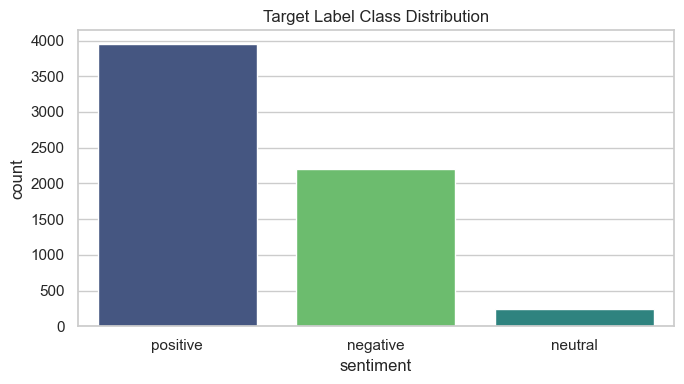


🔢 Encoded Label Mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


In [4]:
# --- Check missing values ---
print("🛡️ Checking for Missing Values:")
print(df[['cleaned_text', 'sentiment']].isnull().sum())

# --- Check class distribution (Calculates counts and exact percentages) ---
print("\n📊 Sentiment Class Distribution Counts & Percentages:")
counts = df['sentiment'].value_counts()
percentages = df['sentiment'].value_counts(normalize=True) * 100

# Generate a clean, structured table format for the console output
distribution_df = pd.DataFrame({
    'Count': counts,
    'Percentage': percentages.map("{:.2f}%".format)
})
print(distribution_df)

# Your original plot code remains completely untouched and pristine
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df, 
    x='sentiment', 
    order=['positive', 'negative', 'neutral'], 
    hue='sentiment',     
    palette='viridis', 
    legend=False         
)
plt.title('Target Label Class Distribution')
plt.tight_layout()
plt.show()

# --- Encode labels ---
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
LABEL_NAMES = list(le.classes_)
print(f"\n🔢 Encoded Label Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

### STEP 5: Feature Engineering (Text Vectorisation (TF-IDF))

Text columns cannot be interpreted directly by traditional machine learning algorithms. We establish a **TF-IDF Vectorizer** (Term Frequency-Inverse Document Frequency) restricted to the top $10,000$ features using both unigrams and bigrams. We intentionally activate `sublinear_tf=True` to apply logarithmic frequency scaling, ensuring hyper-frequent background tokens do not disproportionately bias the mathematical weights of our models.

In [5]:
# --- TF-IDF ---
# Setup advanced vectorizer parameters to scale term weights dynamically
vectorizer = TfidfVectorizer(
    max_features=10000, 
    ngram_range=(1, 2),
    sublinear_tf=True,  # Scales term frequency logarithmically to dampen hyper-frequent terms
    min_df=2            # Eliminates rare terms appearing only once in the entire corpus
)

### STEP 6: Train/Test Split

To maintain rigorous scientific evaluation standards, the dataset is segmented using a stratified methodology into **70% Training, 10% Validation, and 20% Testing** sets. Stratification enforces that each data split mirrors the exact minority-to-majority class ratio found in the original population database, protecting our evaluation against accidental sampling variance skewing.

In [6]:
X = df['cleaned_text']
y = df['label']

# Step 1: Extract 20% validation test data
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
# Step 2: Split the remaining 80% into 70% train and 10% confirmation validation (0.125 * 0.80 = 0.10)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=SEED, stratify=y_temp
)

# Transforming text fields into calculated numeric matrices
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"📈 Strategic Data Splits -> Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

📈 Strategic Data Splits -> Train: 4476 | Val: 640 | Test: 1279


### STEP 7: Core Model Training & Benchmarking Matrix

#### 7.1 Model 1 (Multinomial Naive Bayes)

We deploy **Multinomial Naive Bayes** as our probabilistic baseline classifier. Configured with Laplace smoothing (`alpha=0.1`), it evaluates word conditional probability distributions asynchronously. It is exceptionally lightweight, making it an excellent high-performance candidate for fast deployment.

In [7]:
# --- Multinomial Naive Bayes ---
print("⏳ Training Multinomial Naive Bayes Model...")
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)
print("✅ Naive Bayes trained.")

# Print classification report immediately under the model
print(classification_report(y_test, y_pred_nb, target_names=LABEL_NAMES, zero_division=0))

⏳ Training Multinomial Naive Bayes Model...
✅ Naive Bayes trained.
              precision    recall  f1-score   support

    negative       0.79      0.91      0.85       441
     neutral       0.00      0.00      0.00        49
    positive       0.94      0.92      0.93       789

    accuracy                           0.88      1279
   macro avg       0.58      0.61      0.59      1279
weighted avg       0.85      0.88      0.87      1279



#### 7.2 Model 2 (Logistic Regression)

We train a **Logistic Regression** classifier optimized with regularized tuning weights. Crucially, we pass the parameter `class_weight='balanced'`. This mathematically penalizes majority-class misclassifications more heavily, forcing the objective convergence cost function to care equally about our tiny minority `neutral` category sample spaces.

In [8]:
# --- Logistic Regression ---
print("⏳ Training Logistic Regression Model...")
lr_model = LogisticRegression(
    C=0.5, max_iter=1000, 
    class_weight='balanced',  # Handles class imbalance automatically
    random_state=SEED, n_jobs=-1
)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)
print("✅ Logistic Regression trained.")

# Print classification report immediately under the model
print(classification_report(y_test, y_pred_lr, target_names=LABEL_NAMES))

⏳ Training Logistic Regression Model...
✅ Logistic Regression trained.
              precision    recall  f1-score   support

    negative       0.78      0.87      0.82       441
     neutral       0.15      0.18      0.16        49
    positive       0.96      0.88      0.92       789

    accuracy                           0.85      1279
   macro avg       0.63      0.64      0.63      1279
weighted avg       0.86      0.85      0.85      1279



#### 7.3 Model 3 (Linear SVM)
We train a **Linear Support Vector Machine (Linear SVC)**. SVM aims to maximize the geometric margin boundary separating the vector space clusters. Like our Logistic configuration, it incorporates automatic class balancing weights to remain robust against severe label skews.

In [9]:
# --- Linear SVM ---
print("⏳ Training Linear SVM...")
svm_model = LinearSVC(
    C=0.5,
    class_weight='balanced',  # Handles class imbalance automatically
    random_state=SEED
)
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
print("✅ Linear SVM trained.")

# Print classification report immediately under the model
print(classification_report(y_test, y_pred_svm, target_names=LABEL_NAMES))

⏳ Training Linear SVM...
✅ Linear SVM trained.
              precision    recall  f1-score   support

    negative       0.79      0.87      0.83       441
     neutral       0.26      0.14      0.18        49
    positive       0.93      0.90      0.92       789

    accuracy                           0.86      1279
   macro avg       0.66      0.64      0.64      1279
weighted avg       0.86      0.86      0.86      1279



### STEP 8: Model Comparison

We orchestrate a comprehensive, side-by-side benchmarking matrix evaluating all models across key industry standard parameters: **Accuracy, Weighted Precision, Weighted Recall, and Weighted F1-Score**. Simultaneously, we visualize three combined **Confusion Matrices** in an inline subplot grid. This cross-functional diagnostic layout visually demonstrates exactly where each model is misclassifying individual target labels.

In [10]:
models_eval = [
    ('Multinomial Naive Bayes', y_pred_nb),
    ('Logistic Regression', y_pred_lr),
    ('Linear SVM', y_pred_svm)
]

models_dict = {
    'Multinomial Naive Bayes': nb_model,
    'Logistic Regression': lr_model,
    'Linear SVM': svm_model
}

# Loop only to print the complete text reports
for name, preds in models_eval:
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, preds)
    
    # Save the variables into our global summary dict for later cells
    performance_summary[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1,
        'Confusion_Matrix': cm, 'Model_Object': models_dict[name]
    }
    
    print(f"\n=================== {name} Complete Report ===================")
    print(classification_report(y_test, preds, target_names=LABEL_NAMES, zero_division=0))


=================== Multinomial Naive Bayes Complete Report ===================
              precision    recall  f1-score   support

    negative       0.79      0.91      0.85       441
     neutral       0.00      0.00      0.00        49
    positive       0.94      0.92      0.93       789

    accuracy                           0.88      1279
   macro avg       0.58      0.61      0.59      1279
weighted avg       0.85      0.88      0.87      1279


=================== Logistic Regression Complete Report ===================
              precision    recall  f1-score   support

    negative       0.78      0.87      0.82       441
     neutral       0.15      0.18      0.16        49
    positive       0.96      0.88      0.92       789

    accuracy                           0.85      1279
   macro avg       0.63      0.64      0.63      1279
weighted avg       0.86      0.85      0.85      1279


=================== Linear SVM Complete Report ===================
            

📊 Generating comparative confusion matrix plots...


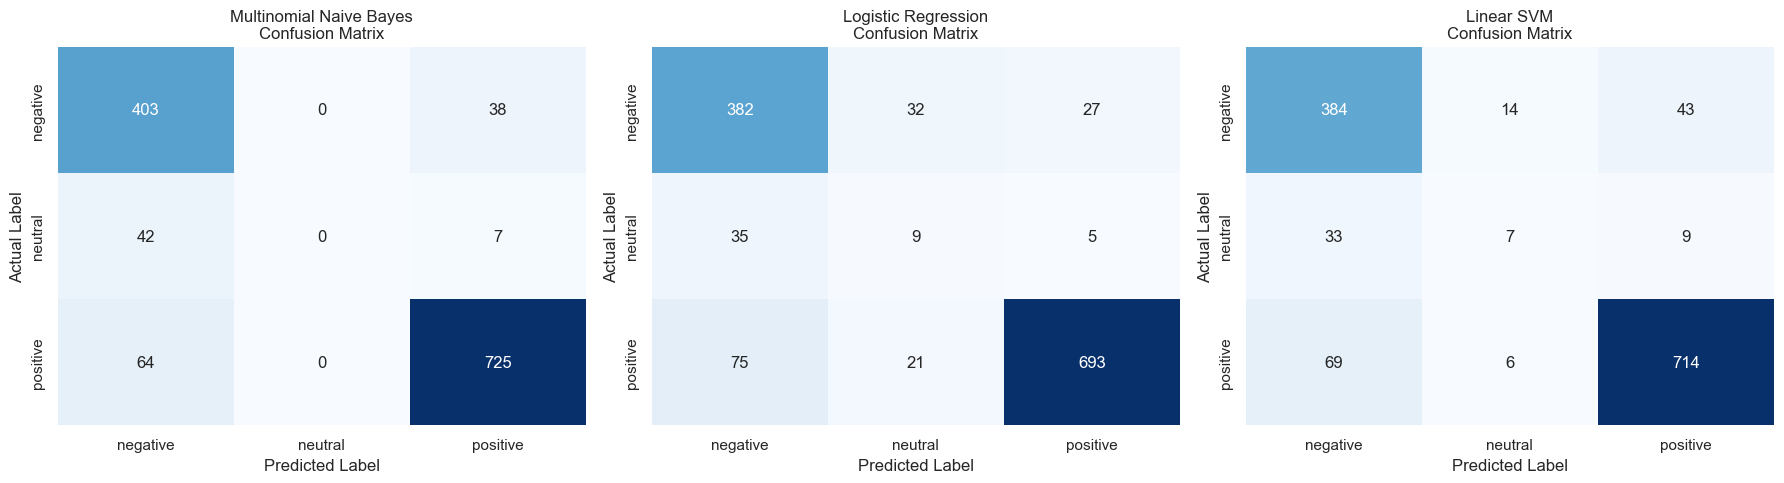


✅ Matrix comparison plots saved successfully as 'models_confusion_matrix_comparison.png'!


In [11]:
print("📊 Generating comparative confusion matrix plots...")

# 1. CRITICAL: You must define the subplots grid inside the SAME cell where you draw!
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Map each model to its respective subplot axis
plot_mapping = [
    ('Multinomial Naive Bayes', axes[0]),
    ('Logistic Regression', axes[1]),
    ('Linear SVM', axes[2])
]

# 2. Loop through and draw the heatmaps on the created axes
for name, ax in plot_mapping:
    # Retrieve the confusion matrix saved from the previous cell
    cm = performance_summary[name]['Confusion_Matrix']
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues', 
        ax=ax, 
        xticklabels=LABEL_NAMES, 
        yticklabels=LABEL_NAMES, 
        cbar=False
    )
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('Actual Label')

# 3. Adjust layout and save the finalized image asset
plt.tight_layout()
plt.savefig('models_confusion_matrix_comparison.png', dpi=300)
plt.show()

print("\n✅ Matrix comparison plots saved successfully as 'models_confusion_matrix_comparison.png'!")

### STEP 9: Select Best Model

We programmatically identify the definitive champion model architecture by maximizing the weighted **F1-Score** metric. F1-Score represents the harmonic mean of precision and recall, serving as the only truly reliable performance indicator under severe dataset class distribution skews. The best-performing model algorithm will be dynamically extracted as our final runtime engine.

In [12]:
print("===================  SYSTEM COMPARISON MATRIX  ===================")
summary_rows = []
for name, metrics in performance_summary.items():
    summary_rows.append({
        'Model Pipeline': name,
        'Accuracy': f"{metrics['Accuracy']*100:.2f}%",
        'Precision': f"{metrics['Precision']:.4f}",
        'Recall': f"{metrics['Recall']:.4f}",
        'F1-Score': f"{metrics['F1-Score']:.4f}"
    })
print(pd.DataFrame(summary_rows).to_string(index=False))

# Automatically select the configuration with the highest validation F1-Score
champion_name = max(performance_summary, key=lambda k: performance_summary[k]['F1-Score'])
print(f"\n🚀 Selected Champion Model Strategy: {champion_name}")

===================  SYSTEM COMPARISON MATRIX  ===================
         Model Pipeline Accuracy Precision Recall F1-Score
Multinomial Naive Bayes   88.19%    0.8538 0.8819   0.8663
    Logistic Regression   84.75%    0.8629 0.8475   0.8533
             Linear SVM   86.40%    0.8574 0.8640   0.8592

🚀 Selected Champion Model Strategy: Multinomial Naive Bayes


### STEP 10: Batch Prediction

In [13]:
champion_model_obj = performance_summary[champion_name]['Model_Object']

# Perform batch inferencing over the global repository dataset
X_all_tfidf = vectorizer.transform(df['cleaned_text'])
df['predicted_label'] = champion_model_obj.predict(X_all_tfidf)
df['predicted_sentiment'] = le.inverse_transform(df['predicted_label'])

# Save predictions output payload file for Dashboard ingestion (Member 4)
output_batch_csv = "batch_prediction.csv"
df[['review_id', 'cleaned_text', 'rating', 'sentiment', 'predicted_sentiment']].to_csv(output_batch_csv, index=False)
print(f"📦 Pipeline exported logs generated successfully at: '{output_batch_csv}'")

📦 Pipeline exported logs generated successfully at: 'batch_prediction.csv'


### STEP 11: Save Best Model

In [14]:
# Create deployment wrapper pipeline bundling preprocessors and models together
deployment_pipeline = Pipeline([
    ('vectorizer', vectorizer),
    ('classifier', champion_model_obj)
])

# Save pipeline out file for high-performance Spark streaming inference (Member 3)
output_pipeline_pkl = "best_sentiment_model.pkl"
joblib.dump(deployment_pipeline, output_pipeline_pkl)
print(f"💾 Production runtime deployment pipeline saved at: '{output_pipeline_pkl}'")


💾 Production runtime deployment pipeline saved at: 'best_sentiment_model.pkl'
